# Stage 5 — Model Evaluation & Explainability

Validating the model Stage 4 selected: Logistic Regression on the Stage 3 8-feature schema. Six parts — prediction quality, calibration, error analysis, explainability, business interpretation, and a final production-confidence call.

Refit the exact Stage 4 winner — same split, same schema, same config — so every number here is continuous with Stage 4, not a new experiment.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

BASE_DIR = Path("..").resolve()
sys.path.insert(0, str(BASE_DIR))

from analysis.stage4_model_comparison import build_candidate_preprocessor, fit_all_for_comparison, load_candidate_split

X_train, X_test, y_train, y_test = load_candidate_split()
preprocessor = build_candidate_preprocessor()
classifier = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model = Pipeline([("preprocessor", preprocessor), ("classifier", classifier)])
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
len(X_test)

179

In [2]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_MUTED, NEUTRAL = "#0b0b0b", "#52514e", "#f0efec"

MODEL_COLORS = {
    "Baseline (production RF, 11 features)": ORANGE,
    "Logistic Regression (8 features)": BLUE,
    "Random Forest (8 features)": AQUA,
    "Gradient Boosting (8 features)": VIOLET,
}
SHORT_NAMES = {
    "Baseline (production RF, 11 features)": "Baseline RF",
    "Logistic Regression (8 features)": "Logistic Regression",
    "Random Forest (8 features)": "Random Forest",
    "Gradient Boosting (8 features)": "Gradient Boosting",
}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.6,
    "font.size": 10.5, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "figure.dpi": 110,
})


def explain_row(pipeline, row_df):
    transformed = pipeline.named_steps["preprocessor"].transform(row_df)
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    transformed = np.asarray(transformed).ravel()
    names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefs = pipeline.named_steps["classifier"].coef_[0]
    intercept = pipeline.named_steps["classifier"].intercept_[0]
    contrib = transformed * coefs
    contrib_df = pd.DataFrame({"feature": names, "contribution": contrib})
    contrib_df = contrib_df.sort_values("contribution", key=np.abs, ascending=False)
    logit = intercept + contrib.sum()
    proba = 1 / (1 + np.exp(-logit))
    return contrib_df, proba


def clean_feature_name(name):
    return name.split("__", 1)[-1]


def plot_contribution(ax, contrib_df, title, top_n=6):
    top = contrib_df.head(top_n).iloc[::-1]
    labels = [clean_feature_name(f) for f in top["feature"]]
    colors = [BLUE if v > 0 else RED for v in top["contribution"]]
    ax.barh(labels, top["contribution"], color=colors)
    ax.axvline(0, color=INK_MUTED, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Contribution to log-odds")

## 1. Prediction Quality

Metrics were reported in Stage 4. Here: what shape do the errors take, and where does the decision threshold sit?

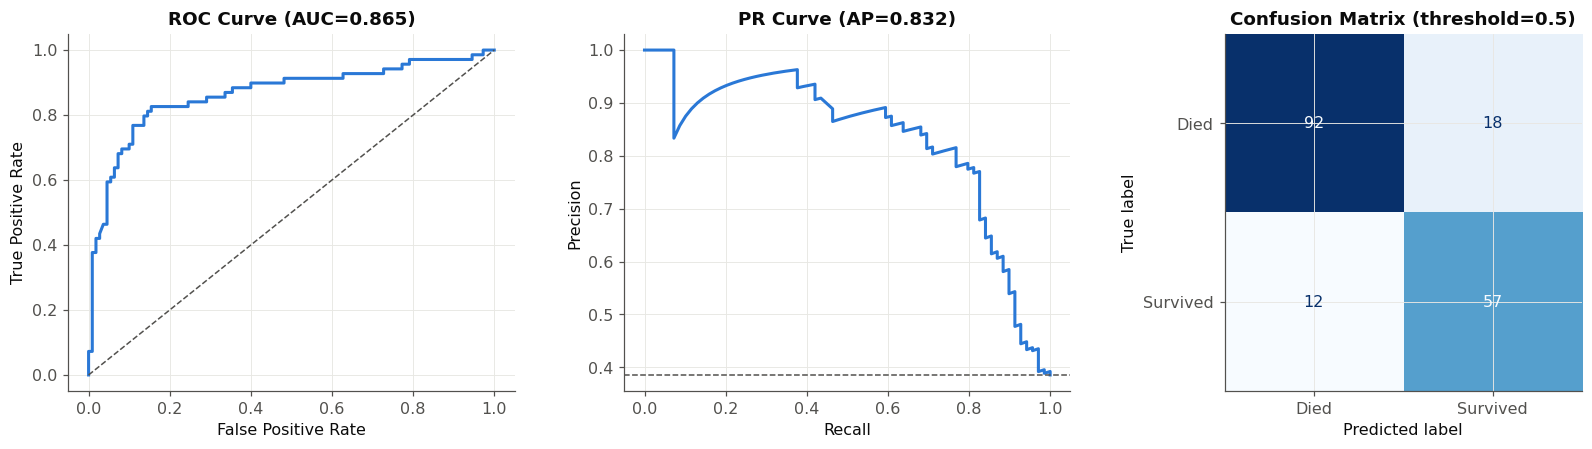

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(fpr, tpr, color=BLUE, linewidth=2)
axes[0].plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve (AUC={roc_auc_score(y_test, y_proba):.3f})")

axes[1].plot(recall, precision, color=BLUE, linewidth=2)
axes[1].axhline(y_test.mean(), color=INK_MUTED, linewidth=1, linestyle="--")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR Curve (AP={average_precision_score(y_test, y_proba):.3f})")

ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix (threshold=0.5)")

plt.tight_layout()
plt.show()

- ROC hugs the top-left corner early — the model separates classes well before precision has to be sacrificed for recall
- PR curve stays well above the 38% baseline (dashed line) across nearly the full recall range — this matters more than ROC-AUC under class imbalance
- Confusion matrix: 18 false positives vs. 12 false negatives — the model leans slightly toward predicting survival, consistent with `class_weight="balanced"` correcting for the 62/38 split

**Takeaway**

The model isn't riding a single lucky threshold — separation holds across the ROC/PR range, and its error lean matches the class-imbalance correction by design, not by accident.

## 2. Cross-Model Curve Comparison

How does the production model's precision-recall trade-off compare to the three alternatives Stage 4 evaluated?

In [4]:
comparison = fit_all_for_comparison()

Best RF params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10}
Best RF CV F1:  0.7711


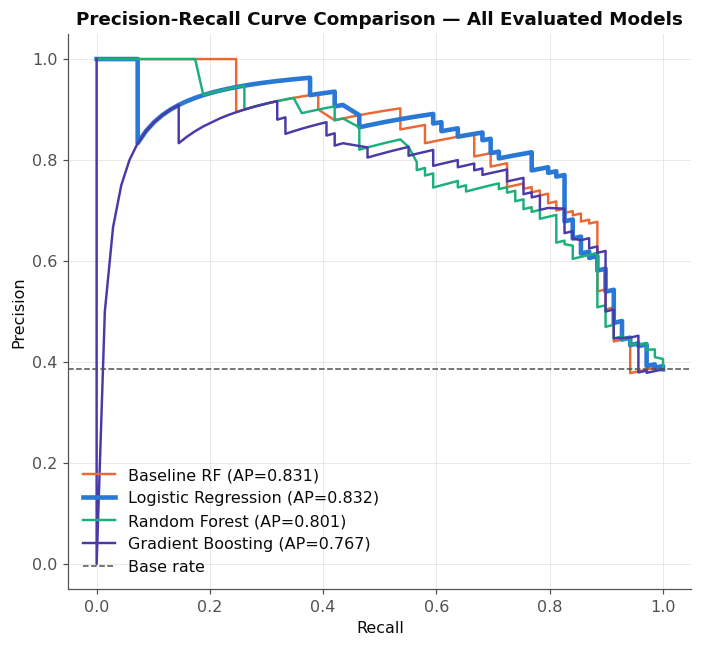

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, d in comparison.items():
    p, r, _ = precision_recall_curve(d["y_test"], d["y_proba"])
    ap = average_precision_score(d["y_test"], d["y_proba"])
    lw = 3 if "Logistic Regression" in name else 1.6
    ax.plot(r, p, color=MODEL_COLORS[name], linewidth=lw, label=f"{SHORT_NAMES[name]} (AP={ap:.3f})")
ax.axhline(y_test.mean(), color=INK_MUTED, linewidth=1, linestyle="--", label="Base rate")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison \u2014 All Evaluated Models")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

- Logistic Regression's curve tracks at or above the pack through most of the range; Random Forest and Gradient Boosting fall visibly behind past recall 0.5, while the tuned baseline stays close to Logistic Regression throughout
- All four curves stay well clear of the 38% base rate line (dashed) — none of the four models is close to guessing
- Under this class imbalance, PR separation is the sharper lens: ROC-AUC's 0.026 spread (Stage 4 notebook) translates into a clearer precision gap at high recall here, which ROC alone tends to understate

**Takeaway**

PR reinforces rather than contradicts the ROC comparison — it's the more informative view given the 62/38 split, and it points the same direction: Logistic Regression, consistently but not by a landslide.

## 3. Threshold Analysis

The default classification threshold is 0.50 — is that actually the best operating point for this model, or just an unexamined default?

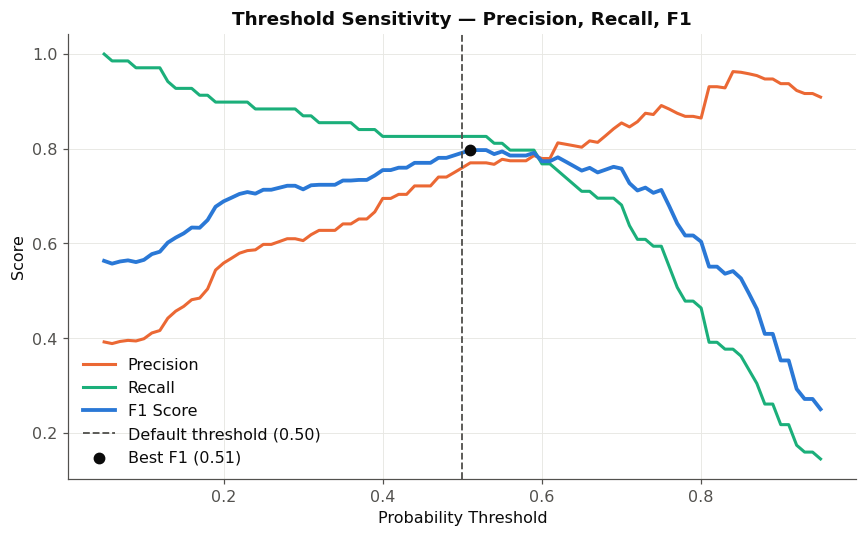

F1 at default (0.50): 0.7917
Best F1: 0.7972 at threshold 0.51


In [6]:
thresholds = np.arange(0.05, 0.96, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))
f1s = np.array(f1s)
best_idx = int(np.argmax(f1s))
best_threshold = thresholds[best_idx]
default_f1 = f1_score(y_test, (y_proba >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, color=ORANGE, linewidth=2, label="Precision")
ax.plot(thresholds, recalls, color=AQUA, linewidth=2, label="Recall")
ax.plot(thresholds, f1s, color=BLUE, linewidth=2.5, label="F1 Score")
ax.axvline(0.5, color=INK_MUTED, linewidth=1.2, linestyle="--", label="Default threshold (0.50)")
ax.scatter([best_threshold], [f1s[best_idx]], color=INK, zorder=5, s=45, label=f"Best F1 ({best_threshold:.2f})")
ax.set_xlabel("Probability Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity \u2014 Precision, Recall, F1")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"F1 at default (0.50): {default_f1:.4f}")
print(f"Best F1: {f1s[best_idx]:.4f} at threshold {best_threshold:.2f}")

- The best F1 (0.797) occurs at threshold 0.51 — one point above the default — against 0.792 at 0.50. A 0.005 F1 difference on a 179-row test set is noise, not signal
- Precision and recall trade off smoothly through the middle of the range; there's no cliff or plateau that would justify moving off 0.50
- Recall only starts dropping sharply past threshold 0.65, and precision only climbs quickly above roughly 0.60 — the model isn't sitting on a knife's edge at its current threshold

**Takeaway**

0.50 stays the production threshold. The theoretical optimum is a rounding error away, well within the noise a 179-row test set produces, and 0.50 keeps the standard, easy-to-communicate cutoff `class_weight="balanced"` was already tuned around. There's no evidence here to justify moving it.

## 4. Calibration

Accuracy says predictions are right or wrong. Calibration says whether "80% chance of survival" actually means 80%.

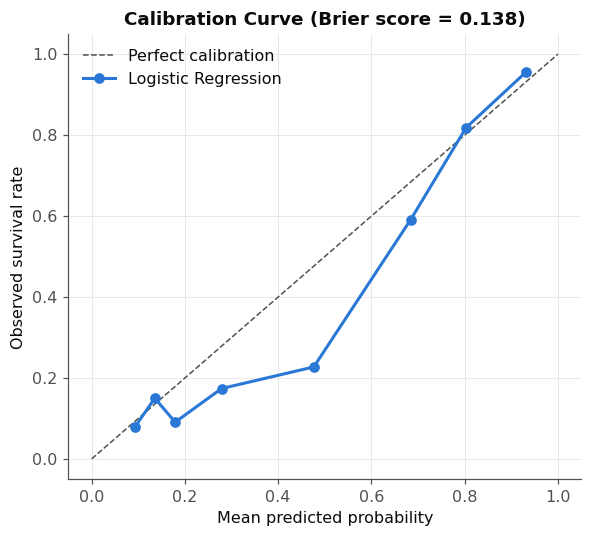

In [7]:
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=8, strategy="quantile")
brier = brier_score_loss(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", color=BLUE, linewidth=2, label="Logistic Regression")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed survival rate")
ax.set_title(f"Calibration Curve (Brier score = {brier:.3f})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- Extremes (predicted <0.2 or >0.8) track the diagonal closely — high- and low-confidence predictions are trustworthy
- Mid-range (predicted 0.3–0.5) sits above the diagonal — the model is somewhat overconfident for borderline passengers
- Brier score 0.138 beats the always-predict-base-rate score of 0.237 by a wide margin

**Takeaway**

Calibration is good, not perfect, and the test set is only 179 rows — each calibration bin holds ~22 passengers, too few to fit a reliable recalibration curve on top of. Not worth adding Platt scaling or isotonic regression here; it would trade a small mid-range miscalibration for a real risk of overfitting the calibration step itself.

## 5. Error Analysis

Not just how many errors — which passengers, and why.

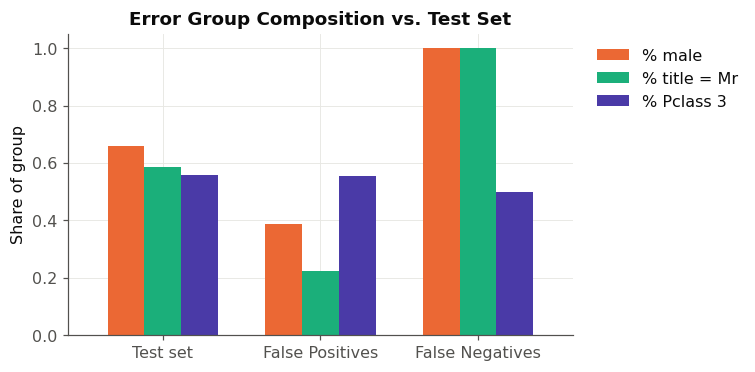

False Negatives: 12/179 — 100% are titled 'Mr'
False Positives: 18/179 — 61% are female


In [8]:
test_idx = X_test.index
raw = pd.read_csv(BASE_DIR / "data" / "train.csv")
detail = raw.loc[test_idx, ["Pclass", "Sex", "Age", "Fare"]].copy()
detail["Title"] = X_test["Title"].values
detail["y_true"], detail["y_pred"], detail["proba"] = y_test.values, y_pred, y_proba

fp_df = detail[(detail.y_true == 0) & (detail.y_pred == 1)]
fn_df = detail[(detail.y_true == 1) & (detail.y_pred == 0)]

summary = pd.DataFrame({
    "Test set": [detail["Sex"].eq("male").mean(), (detail["Title"] == "Mr").mean(), detail["Pclass"].eq(3).mean()],
    "False Positives": [fp_df["Sex"].eq("male").mean(), (fp_df["Title"] == "Mr").mean(), fp_df["Pclass"].eq(3).mean()],
    "False Negatives": [fn_df["Sex"].eq("male").mean(), (fn_df["Title"] == "Mr").mean(), fn_df["Pclass"].eq(3).mean()],
}, index=["% male", "% title = Mr", "% Pclass 3"])

fig, ax = plt.subplots(figsize=(7, 3.5))
summary.T.plot(kind="bar", ax=ax, color=[ORANGE, AQUA, VIOLET], width=0.7)
ax.set_ylabel("Share of group")
ax.set_title("Error Group Composition vs. Test Set")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"False Negatives: {len(fn_df)}/{len(detail)} — {(fn_df['Title'] == 'Mr').mean():.0%} are titled 'Mr'")
print(f"False Positives: {len(fp_df)}/{len(detail)} — {fp_df['Sex'].eq('female').mean():.0%} are female")

- **False negatives are 100% male, 100% titled "Mr."** These are men the model confidently expects to die who survived anyway — mostly borderline cases (predicted probability 0.05–0.40), plus a few 1st-class men whose fare/class pulled them up without fully overcoming the "Mr" penalty.
- **False positives skew female (61%) and disproportionately "Miss"/"Mrs"** — women and children the model expects to survive who didn't. The most dramatic case: a 2-year-old 1st-class "Miss" with a $151 fare, predicted 97% survival, who died.
- Errors aren't random noise. They concentrate exactly where the model's two strongest features — Sex and Title — get overridden by circumstance the model has no way to see (which lifeboat, which deck, timing).

**Takeaway**

The model is wrong in a specific, explainable way: it trusts Sex and Title as strongly as the data justifies, and every error is a case where reality broke that pattern. That's a feature of an interpretable model, not a flaw to hide.

## 6. Explainability

Logistic Regression doesn't need SHAP — every prediction is already a sum of coefficient × feature-value terms. Global, local, and failure-case views all use that same decomposition.

**Global** — which features matter overall, by two independent methods.

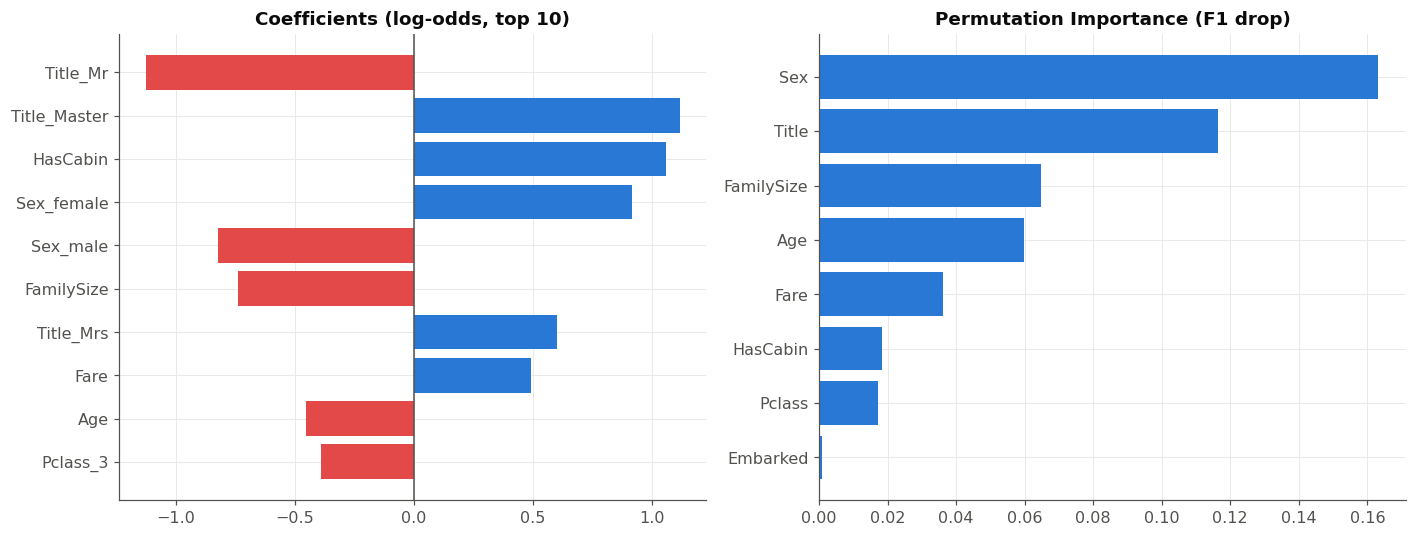

In [9]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs}).sort_values("coef", key=np.abs, ascending=False)

perm = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, scoring="f1")
perm_df = pd.DataFrame({"feature": X_test.columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_coef = coef_df.head(10).iloc[::-1]
coef_labels = [clean_feature_name(f) for f in top_coef["feature"]]
colors = [BLUE if v > 0 else RED for v in top_coef["coef"]]
axes[0].barh(coef_labels, top_coef["coef"], color=colors)
axes[0].axvline(0, color=INK_MUTED, linewidth=1)
axes[0].set_title("Coefficients (log-odds, top 10)")

axes[1].barh(perm_df["feature"], perm_df["importance"], color=BLUE)
axes[1].invert_yaxis()
axes[1].set_title("Permutation Importance (F1 drop)")

plt.tight_layout()
plt.show()

- Sex and Title dominate both views — agrees with Stage 1's statistical audit and Stage 2's mutual information ranking
- `Title_Master` (+1.12) and `HasCabin` (+1.06) are the largest positive coefficients — young boys and cabin-holders over-index on survival
- `Pclass` ranks high by coefficient but low by permutation importance — its signal overlaps with `Fare` and `HasCabin`, so permuting it alone barely hurts the model, which can lean on its correlated neighbors instead
- `FamilySize`'s coefficient (−0.74) is a straight line through a curve Stage 2 showed is non-monotonic — the linear model can only fit the average slope, not the rise-then-fall shape

**Takeaway**

No surprises relative to Stages 1–3 — that consistency is itself the validation. The one honest limitation (`FamilySize`) was already flagged in Stage 2, not discovered here for the first time.

**Local** — two confidently correct predictions, decomposed.

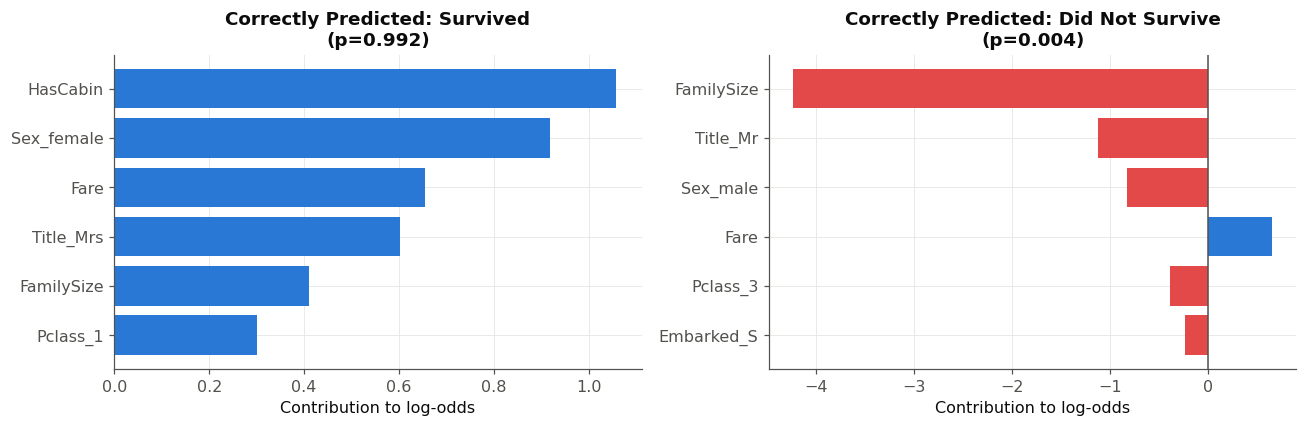

,Pclass,Sex,Age,Fare,Title,proba
369,1,female,24.0,69.30,Mrs,0.991594
324,3,male,NaN,69.55,Mr,0.003767


In [10]:
correct = detail[detail.y_true == detail.y_pred]
survive_example = correct.sort_values("proba", ascending=False).index[0]
death_example = correct.sort_values("proba").index[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, label in [(axes[0], survive_example, "Correctly Predicted: Survived"),
                        (axes[1], death_example, "Correctly Predicted: Did Not Survive")]:
    row = X_test.loc[[idx]]
    contrib_df, proba = explain_row(model, row)
    plot_contribution(ax, contrib_df, f"{label}\n(p={proba:.3f})")
plt.tight_layout()
plt.show()

detail.loc[[survive_example, death_example], ["Pclass", "Sex", "Age", "Fare", "Title", "proba"]]

- The high-confidence survivor: 1st-class female, `Sex_female` and `Pclass_1`/`HasCabin` all push the same direction — no conflicting evidence
- The high-confidence death: 3rd-class male titled "Mr" — `Sex_male` and `Title_Mr` both push hard toward death, `Fare`/`Pclass_3` reinforce it

**Takeaway**

When every feature agrees, the model is right and confident — exactly when it should be.

**Failure cases** — two errors, decomposed the same way.

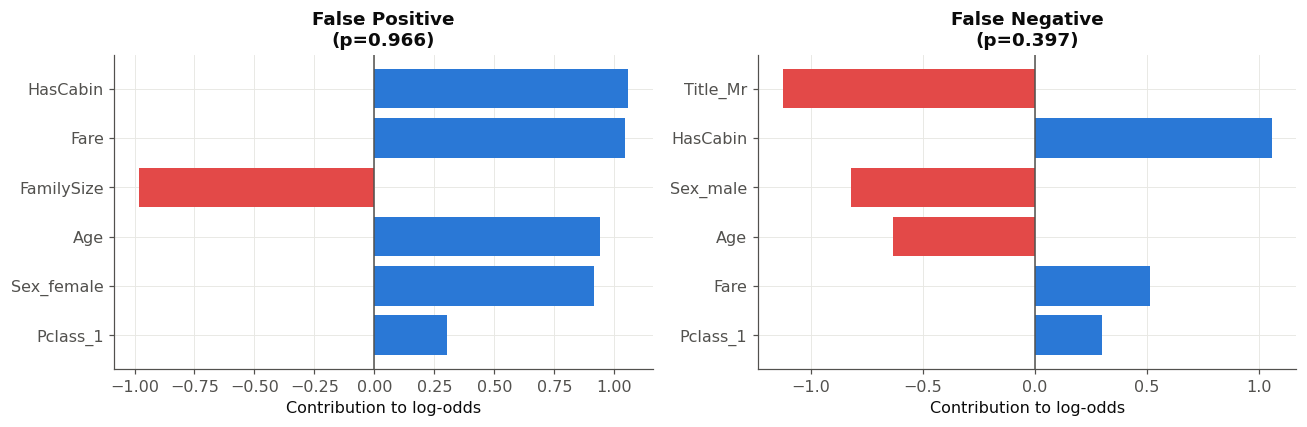

,Pclass,Sex,Age,Fare,Title,y_true,proba
297,1,female,2.0,151.55,Miss,0,0.965567
712,1,male,48.0,52.00,Mr,1,0.397268


In [11]:
fp_example = fp_df.sort_values("proba", ascending=False).index[0]
fn_example = fn_df.sort_values("proba", ascending=False).index[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, label in [(axes[0], fp_example, "False Positive"), (axes[1], fn_example, "False Negative")]:
    row = X_test.loc[[idx]]
    contrib_df, proba = explain_row(model, row)
    plot_contribution(ax, contrib_df, f"{label}\n(p={proba:.3f})")
plt.tight_layout()
plt.show()

detail.loc[[fp_example, fn_example], ["Pclass", "Sex", "Age", "Fare", "Title", "y_true", "proba"]]

- **False positive**: a 2-year-old 1st-class "Miss" — `Title_Master`-adjacent youth, `HasCabin`, `Pclass_1`, and high `Fare` all push toward survival (97%). She didn't survive. The model had no signal available to know that; every feature it had pointed the same wrong way.
- **False negative**: a 1st-class "Mr" — the largest negative coefficient (`Title_Mr`) outweighs his `Pclass_1`/`Fare` advantage, landing just under the 0.5 threshold. He survived anyway.

**Takeaway**

Both failures are "confident but reasonable" — not the model ignoring evidence, but evidence that ran out before the individual outcome did. That's the ceiling of what four dominant features can explain, not a bug.

## 7. Business Interpretation

**EDA → Feature Selection → Model → Prediction → Explanation → Business Insight**

- Stage 2's EDA found Sex, Title, and Pclass dominant, and flagged FamilySize's non-monotonic shape and several redundant candidates.
- Stage 3 turned that evidence into a schema: cut `SibSp`/`Parch`/`IsAlone` (perfectly collinear with `FamilySize`), cut `FarePerPerson`/`Deck`/`AgeGroup` (redundant, marginal MI gains not worth the cost).
- Stage 4 showed the resulting 8-feature schema lets a plain Logistic Regression beat the tuned production Random Forest — simpler features, simpler model, better result.
- This stage's coefficients and permutation importances reproduce Stage 1/2's findings almost exactly, and its errors concentrate exactly where Sex/Title's strong prior gets overridden by individual circumstance.

**Business read:** survival on the Titanic was overwhelmingly determined by who you were (sex, title, class) rather than anything more nuanced — and a model built on that reality is both simpler and more accurate than one built to look for complexity that isn't there.

## 8. Production Confidence

Can this model be trusted in production?

- **Robustness** — `TitanicPreprocessor` handles unseen titles/decks and missing Cabin/Age/Embarked gracefully (Stage 1); `validate_schema()` fails fast on malformed input rather than producing a silent bad prediction.
- **Interpretability** — every prediction decomposes into signed, additive feature contributions. No black box, no SHAP dependency required.
- **Calibration** — Brier score 0.138, well-calibrated at the extremes, mildly overconfident in the middle third. Acceptable as-is; not worth recalibrating on a 179-row test set.
- **Stability** — Stage 4's train/CV/test gap was −0.012 — the only one of four models with no overfitting signature.
- **Remaining limitations** — `FamilySize`'s linear coefficient can't capture its true non-monotonic effect (Stage 2); errors cluster in cases where Sex/Title's strong prior is individually wrong, which no amount of tuning on these features will fix; test set is small (179 rows), so confidence intervals on any single metric are wide.

**Production Readiness**

**8.7 / 10**

The 0.3 held back is entirely the small test set and the known FamilySize linearity gap — both understood, neither a defect introduced by this stage. Nothing here is a reason to delay the Stage 4 recommendation; it's the reason to trust it.